# FeCoNiCrV K/CTE Optimization: Three-Way Comparison

**Objective:** Maximize K / |CTE| ratio

**Strategies:**
1. Pure QEHVI (Full Exploitation)
2. Pure MESMO (Full Exploration)
3. LLM Agent-Driven BO (Adaptive)

This notebook runs all three strategies and compares their performance.
- All strategies use the SAME initial samples for fair comparison
- Proper seeding ensures reproducibility
- Results are saved to unique directories to avoid duplicates

## Imports and Global Setup

In [1]:
import os
import gc
import time
import shutil
from datetime import datetime
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple

import sys
sys.path.append(".")

from dotenv import load_dotenv
load_dotenv()

from core.design_space import DesignSpace
from core.truth_interface import TruthModelEvaluator
from core.gp_models import GPModelManager
from core.acquisition_functions import AcquisitionFunctionManager
from core.agent_manager import BOAgent, ResourceEvent
from core.fixed_policy import PureQEHVI, PureMESMO
from core.logging_utils import LoggingManager
from core.visualization import VisualizationManager

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.double

print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.8.0+cu128


## Problem Configuration (FeCoNiCrV)

In [2]:
# Design space: 5D Fe-Co-Ni-Cr-V simplex
COMPONENTS = [
    ("Fe", 0.10, 0.40),
    ("Co", 0.10, 0.40),
    ("Ni", 0.10, 0.40),
    ("Cr", 0.10, 0.40),
    ("V",  0.10, 0.40),
]
STEP = 0.025
SEED = 42 # Master seed for reproducibility

design_space = DesignSpace(components=COMPONENTS, step=STEP, seed=SEED)
bounds_np = design_space.get_bounds()  # (2, 5)
bounds_t = torch.tensor(bounds_np, dtype=DTYPE, device=DEVICE)

print(f"\nDesign space created with {len(design_space.space)} valid compositions")

# Truth model paths (RF + scalers)
MODEL_PATH = "ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl"
X_SCALER_PATH = "ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/x_scaler.pkl"
Y_SCALER_PATH = "ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/y_scaler.pkl"

def postprocess_outputs(preds_raw: np.ndarray) -> np.ndarray:
    """
    RF output (based on TARGET_COLS order):
      preds_raw[:,0] = CTE_micro (x 10^(-6) 1/K)
      preds_raw[:,1] = K (W/mK)
    
    We want:
      Y[:,0] = |CTE| (absolute value)
      Y[:,1] = K
    """
    cte = -1.0 * preds_raw[:, 0]  # CTE is at index 0
    k = preds_raw[:, 1]           # K is at index 1
    return np.column_stack([cte, k])

# Objective names
OBJ1_NAME = "CTE"  # Y[:,0]
OBJ2_NAME = "K"    # Y[:,1]

# Score function: maximize K / |CTE|
def score_fn(Y: np.ndarray) -> np.ndarray:
    cte = Y[:, 0]  # |CTE|
    k = Y[:, 1]    # K
    return k / (np.abs(cte) + 1e-12)

SCORE_NAME = "K / |CTE|"

print(f"\nObjectives: {OBJ1_NAME}, {OBJ2_NAME}")
print(f"Score metric: {SCORE_NAME}")

[DesignSpace] Generated 8976 valid compositions for 5 components: Fe, Co, Ni, Cr, V

Design space created with 8976 valid compositions

Objectives: CTE, K
Score metric: K / |CTE|


## Compute Output Normalization Parameters

In [3]:
print("\n" + "="*80)
print("COMPUTING OUTPUT NORMALIZATION PARAMETERS")
print("="*80)

# Sample design space to estimate output statistics
print("\n[Setup] Sampling design space to compute normalization statistics...")
sample_X = design_space.sample(n=100, method='sobol')

# Create temporary evaluator WITHOUT normalization to get raw outputs
temp_evaluator = TruthModelEvaluator(
    model_path=MODEL_PATH,
    x_scaler_path=X_SCALER_PATH,
    y_scaler_path=Y_SCALER_PATH,
    postprocess_outputs=postprocess_outputs,
    normalize_outputs=False,  # CRITICAL: Get raw outputs first
)

# Evaluate sample to get output statistics
sample_result = temp_evaluator.evaluate(sample_X)
sample_Y = sample_result.y

# Compute normalization parameters
y_mean = np.mean(sample_Y, axis=0)
y_std = np.std(sample_Y, axis=0)

print(f"\nNormalization parameters computed from {len(sample_X)} samples:")
print(f"  {OBJ1_NAME}: mean={y_mean[0]:.4f}, std={y_std[0]:.4f}")
print(f"  {OBJ2_NAME}: mean={y_mean[1]:.4f}, std={y_std[1]:.4f}")
print(f"  Scale ratio (std[K]/std[CTE]): {y_std[1]/y_std[0]:.2f}x")

# Store normalization parameters
normalization_params = {'mean': y_mean, 'std': y_std}

# Clean up temporary evaluator
temp_evaluator.cleanup()
del temp_evaluator
gc.collect()

print("\n✓ Normalization parameters computed successfully")
print("="*80)


COMPUTING OUTPUT NORMALIZATION PARAMETERS

[Setup] Sampling design space to compute normalization statistics...
[TruthEvaluator] Loading model from ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl
[TruthEvaluator] Model loaded successfully
[TruthEvaluator] RF outputs: 2

Normalization parameters computed from 100 samples:
  CTE: mean=-12.2504, std=2.4196
  K: mean=10.9706, std=12.8937
  Scale ratio (std[K]/std[CTE]): 5.33x
[TruthEvaluator] Cleanup called


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



✓ Normalization parameters computed successfully


## BO Configuration

In [4]:
# BO parameters
INIT_N = 5              # Initial random samples
ITERS = 20              # BO iterations
MC_SAMPLES = 256        # Monte Carlo samples for acquisition
POOL_SUBSAMPLE = 5000   # Subsample pool size (None = use full space)
TOTAL_BATCH_SIZE = 5    # Points per iteration

# Resource constraints (for LLM agent)
TOTAL_BUDGET = 10000.0    # $ total budget
TOTAL_TIME = 20.0         # weeks total time
COST_PER_POINT = 100.0    # $ per experiment
TIME_PER_ITERATION = 1.0  # weeks per iteration

# LLM agent configuration
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
AGENT_MODEL = "gpt-4o"
AGENT_TEMPERATURE = 0.7
MAX_REASONING_STEPS = 5

PROBLEM_DESCRIPTION = """
High Entropy Alloy (HEA) optimization in the Fe-Co-Ni-Cr-V composition space.

Objectives:
- Minimize CTE (Coefficient of Thermal Expansion)
- Maximize K (Thermal Conductivity)

Goal: Maximize K / |CTE| ratio

Input space: 5D compositions (Fe, Co, Ni, Cr, V), each in [0.1, 0.4], summing to 1.0.

You should balance exploration and exploitation given the qEHVI and MO-MESMO 
acquisition values for each option to best reach the goal within budget and time constraints.
"""

# Output configuration - Use timestamp to avoid overwriting
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"results/FeCoNiCrV_K_CTE_Comparison_{TIMESTAMP}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CREATE_VIS = True   # Create visualizations (pentagon plots for 5D)
CREATE_GIF = True   # Create animated GIFs

print(f"\nBO Configuration:")
print(f"  Initial samples: {INIT_N}")
print(f"  Iterations: {ITERS}")
print(f"  Batch size: {TOTAL_BATCH_SIZE}")
print(f"  Total evaluations: {INIT_N + ITERS * TOTAL_BATCH_SIZE}")
print(f"\nOutput directory: {OUTPUT_DIR}")


BO Configuration:
  Initial samples: 5
  Iterations: 20
  Batch size: 5
  Total evaluations: 105

Output directory: results/FeCoNiCrV_K_CTE_Comparison_20260204_203614


## Generate Shared Initial Samples

**CRITICAL:** All strategies must start with the same initial samples for fair comparison.

In [5]:
# Set seed and generate initial samples ONCE
print(f"\n{'='*80}")
print("GENERATING SHARED INITIAL SAMPLES")
print(f"{'='*80}")

# Reset seeds
np.random.seed(SEED)
torch.manual_seed(SEED)

# Sample initial points
X0_SHARED = design_space.sample(INIT_N, method="random")
print(f"\nSampled {INIT_N} initial compositions:")
for i, x in enumerate(X0_SHARED):
    comp_str = ", ".join([f"{label}={val:.3f}" for label, val in zip(design_space.labels, x)])
    print(f"  {i+1}. {comp_str}")

# Create temporary evaluator for initial evaluation
# This evaluator will use normalization since we need raw outputs for display
# but normalized outputs for the actual BO runs
temp_evaluator = TruthModelEvaluator(
    model_path=MODEL_PATH,
    x_scaler_path=X_SCALER_PATH,
    y_scaler_path=Y_SCALER_PATH,
    postprocess_outputs=postprocess_outputs,
    normalize_outputs=False,  # Get raw outputs for display
)

# Evaluate initial points
result0 = temp_evaluator.evaluate(X0_SHARED)
Y0_SHARED_RAW = result0.y  # These are RAW (denormalized) outputs

# Also get normalized version for BO strategies
temp_evaluator_norm = TruthModelEvaluator(
    model_path=MODEL_PATH,
    x_scaler_path=X_SCALER_PATH,
    y_scaler_path=Y_SCALER_PATH,
    postprocess_outputs=postprocess_outputs,
    normalize_outputs=True,
    normalization_params=normalization_params,
)

result0_norm = temp_evaluator_norm.evaluate(X0_SHARED)
Y0_SHARED_NORMALIZED = result0_norm.y  # Normalized for GP

# Clean up
temp_evaluator.cleanup()
temp_evaluator_norm.cleanup()
del temp_evaluator, temp_evaluator_norm
gc.collect()

print(f"\nInitial objective values (RAW scale for interpretability):")
for i, (cte, k) in enumerate(Y0_SHARED_RAW):
    score = score_fn(Y0_SHARED_RAW[i:i+1])[0]
    print(f"  {i+1}. CTE={cte:.4f}, K={k:.4f}, Score={score:.4f}")

# Save shared initial data (RAW outputs)
shared_init_path = os.path.join(OUTPUT_DIR, "shared_initial_samples.csv")
init_df = pd.DataFrame(X0_SHARED, columns=design_space.labels)
Y0_SHARED_RAW = np.abs(Y0_SHARED_RAW)
init_df["CTE"] = Y0_SHARED_RAW[:, 0]
init_df["K"] = Y0_SHARED_RAW[:, 1]
init_df["score"] = score_fn(Y0_SHARED_RAW)
init_df.to_csv(shared_init_path, index=False)
print(f"\nShared initial samples saved to: {shared_init_path}")

print(f"\n{'='*80}")
print("All experiments will use these exact same initial samples")
print(f"{'='*80}")


GENERATING SHARED INITIAL SAMPLES

Sampled 5 initial compositions:
  1. Fe=0.275, Co=0.100, Ni=0.125, Cr=0.150, V=0.350
  2. Fe=0.175, Co=0.150, Ni=0.300, Cr=0.100, V=0.275
  3. Fe=0.225, Co=0.175, Ni=0.200, Cr=0.275, V=0.125
  4. Fe=0.100, Co=0.250, Ni=0.200, Cr=0.325, V=0.125
  5. Fe=0.175, Co=0.150, Ni=0.175, Cr=0.175, V=0.325
[TruthEvaluator] Loading model from ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl
[TruthEvaluator] Model loaded successfully
[TruthEvaluator] RF outputs: 2
[TruthEvaluator] Loading model from ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl
[TruthEvaluator] Using provided normalization:
  Mean: [-12.25035938  10.9706266 ]
  Std:  [ 2.41957162 12.89373718]
[TruthEvaluator] Model loaded successfully
[TruthEvaluator] RF outputs: 2
[TruthEvaluator] Cleanup called
[TruthEvaluator] Cleanup called


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Initial objective values (RAW scale for interpretability):
  1. CTE=-10.0039, K=0.1000, Score=0.0100
  2. CTE=-10.9942, K=4.0849, Score=0.3715
  3. CTE=-11.5190, K=6.1244, Score=0.5317
  4. CTE=-11.5359, K=5.9221, Score=0.5134
  5. CTE=-10.0100, K=0.1614, Score=0.0161

Shared initial samples saved to: results/FeCoNiCrV_K_CTE_Comparison_20260204_203614\shared_initial_samples.csv

All experiments will use these exact same initial samples


## Helper Function - Run BO Experiment

In [6]:
def run_bo_experiment(
    experiment_name: str,
    strategy,  # Can be PureQEHVI, PureMESMO, or BOAgent
    X0_init: np.ndarray,  # Shared initial X
    Y0_init_raw: np.ndarray,  # Shared initial Y (RAW/denormalized)
    Y0_init_normalized: np.ndarray,  # Shared initial Y (normalized for GP)
    normalization_params: dict,  # Normalization parameters
    seed: int = SEED,
    create_visualization: bool = CREATE_VIS,
) -> Tuple[np.ndarray, np.ndarray, LoggingManager]:
    """
    Run a single BO experiment with a given strategy using proper normalization.
    Only computes necessary allocation options:
    - PureQEHVI: Only option 0 (all exploitation)
    - PureMESMO: Only option 5 (all exploration)
    - BOAgent: All 6 options (adaptive selection)

    KEY WORKFLOW:
    1. GP and acquisition use NORMALIZED outputs (mean=0, std=1)
    2. Logging, scoring, and visualization use RAW (denormalized) outputs
    3. Evaluator returns normalized outputs, which we denormalize when needed
    
    Args:
        experiment_name: Name of this experiment
        strategy: PureQEHVI, PureMESMO, or BOAgent
        X0_init: Shared initial X samples (INIT_N, d)
        Y0_init_raw: Shared initial Y values in ORIGINAL scale (INIT_N, 2)
        Y0_init_normalized: Shared initial Y values NORMALIZED (INIT_N, 2)
        normalization_params: Dict with 'mean' and 'std' arrays
        seed: Random seed for BO iterations
        create_visualization: Whether to create visualizations

    Returns:
        X_history: (n, 5) final input history
        Y_history: (n, 2) final output history
        logger: LoggingManager instance
    """
    print(f"\n{'='*80}")
    print(f"[Experiment] {experiment_name}")
    print(f"[Strategy] {type(strategy).__name__}")
    print(f"{'='*80}")
    
    # Set seeds
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Create evaluator WITH normalization for this experiment
    evaluator = TruthModelEvaluator(
        model_path=MODEL_PATH,
        x_scaler_path=X_SCALER_PATH,
        y_scaler_path=Y_SCALER_PATH,
        postprocess_outputs=postprocess_outputs,
        normalize_outputs=True,  # CRITICAL: Enable normalization
        normalization_params=normalization_params,
    )

    # Setup managers
    gp_manager = GPModelManager(bounds=bounds_t)
    acq_manager = AcquisitionFunctionManager(
        bounds=bounds_t,
        raw_samples=256,
    )
    
    # Setup logging
    exp_dir = os.path.join(OUTPUT_DIR, experiment_name)
    os.makedirs(exp_dir, exist_ok=True)
    logger = LoggingManager(exp_dir, experiment_name)
    
    # Setup visualization (pentagon plot for 5D)
    vis_manager = None
    if create_visualization:
        vis_manager = VisualizationManager(
            design_space=design_space,
            log_dir=exp_dir,
            experiment_name=experiment_name,
            normalization_params=normalization_params,
            obj1_name=OBJ1_NAME,
            obj2_name=OBJ2_NAME,
        )
    
    # Initialize with SHARED samples
    print(f"\n[Init] Using {len(X0_init)} shared initial samples")
    
    # For GP and acquisition: use NORMALIZED outputs
    X_torch = torch.tensor(X0_init.copy(), dtype=DTYPE, device=DEVICE)
    Y_torch_normalized = torch.tensor(Y0_init_normalized.copy(), dtype=DTYPE, device=DEVICE)
    
    # For logging and scoring: maintain RAW outputs
    X_history_np = X0_init.copy()
    Y_history_raw_np = Y0_init_raw.copy()
    Y_history_normalized_np = Y0_init_normalized.copy()

    # Compute initial scores (on RAW data)
    scores = score_fn(Y_history_raw_np)
    best_score = float(np.max(scores))
    print(f"[Init] Best {SCORE_NAME}: {best_score:.4f}")

    # Log iteration 0 (with RAW data for interpretability)
    logger.log_iteration(
        iteration=0,
        X_history=X_history_np,
        Y_history=Y_history_raw_np,  # RAW outputs
        n_new_points=len(X0_init),
        strategy=strategy,
        timing=0.0,
        extra_info={"experiment": experiment_name, "shared_init": True},
        acquisition_data=None,
        score_fn=score_fn,
        obj1_name=OBJ1_NAME,
        obj2_name=OBJ2_NAME,
    )
    
    logger.log_evaluations(
        iteration=0,
        X_new=X0_init,
        Y_new=Y0_init_raw,  # RAW outputs
        score_fn=score_fn,
        obj1_name=OBJ1_NAME,
        obj2_name=OBJ2_NAME,
    )

    # Resource tracking (for agent)
    budget_remaining = TOTAL_BUDGET - (INIT_N * COST_PER_POINT)
    time_remaining = TOTAL_TIME - TIME_PER_ITERATION
    
    # Main BO loop
    for iteration in range(1, ITERS + 1):
        iter_start = time.perf_counter()
        print(f"\n[Iter {iteration}/{ITERS}] Starting...")
        
        # Fit GP model on NORMALIZED data
        print("[GP] Fitting model on normalized outputs...")
        model = gp_manager.fit_model(X_torch, Y_torch_normalized)
        
        # Compute Pareto front on NORMALIZED data
        print("[Acq] Computing Pareto front on normalized outputs...")
        pareto_Y, ref_point = acq_manager.compute_pareto_front(Y_torch_normalized)
        
        # Sample candidate pool
        if POOL_SUBSAMPLE is not None:
            X_pool_np = design_space.sample(POOL_SUBSAMPLE, method="sobol")
        else:
            X_pool_np = design_space.space.copy()
        X_pool = torch.tensor(X_pool_np, dtype=DTYPE, device=DEVICE)
        
        # ============================================================
        # OPTIMIZED: Compute only necessary allocation options
        # ============================================================
        if isinstance(strategy, PureQEHVI):
            # Pure QEHVI only needs option 0 (all exploitation)
            print("[Strategy] Pure QEHVI - Computing option 0 only (5 exploit, 0 explore)")
            allocation_options = acq_manager.compute_single_allocation_option(
                model=model,
                X_pool=X_pool,
                pareto_Y=pareto_Y,
                ref_point=ref_point,
                mc_samples=MC_SAMPLES,
                n_optimization=TOTAL_BATCH_SIZE,
                n_exploration=0,
            )
        elif isinstance(strategy, PureMESMO):
            # Pure MESMO only needs option 5 (all exploration)
            print("[Strategy] Pure MESMO - Computing option 5 only (0 exploit, 5 explore)")
            allocation_options = acq_manager.compute_single_allocation_option(
                model=model,
                X_pool=X_pool,
                pareto_Y=pareto_Y,
                ref_point=ref_point,
                mc_samples=MC_SAMPLES,
                n_optimization=0,
                n_exploration=TOTAL_BATCH_SIZE,
            )
        else:
            # LLM agent needs all 6 options for adaptive selection
            print("[Strategy] LLM Agent - Computing all 6 allocation options")
            allocation_options = acq_manager.compute_all_allocation_options(
                model=model,
                X_pool=X_pool,
                pareto_Y=pareto_Y,
                ref_point=ref_point,
                mc_samples=MC_SAMPLES,
            )
        
        # Select points based on strategy
        if isinstance(strategy, BOAgent):
            # LLM agent selection
            selected_idx, reasoning, selected_point_arrays = strategy.select_resource_allocation(
                iteration=iteration,
                budget_remaining=budget_remaining,
                time_remaining=time_remaining,
                cost_per_point=COST_PER_POINT,
                time_per_point=TIME_PER_ITERATION,
                X_history=X_torch.cpu().numpy(),
                Y_history=Y_torch_normalized.cpu().numpy(),
                allocation_options=allocation_options,
                max_batch_size=TOTAL_BATCH_SIZE,
                score_fn=score_fn,
            )
            
            if selected_point_arrays:
                X_new_np = np.vstack(selected_point_arrays)
            else:
                # Fallback to balanced option
                print("[Warning] Agent selected no points; using balanced fallback")
                batch = allocation_options.qehvi_batches[2]
                parts = []
                if batch.points.size > 0:
                    parts.append(batch.points)
                if batch.explore_points.size > 0:
                    parts.append(batch.explore_points)
                X_new_np = np.vstack(parts) if parts else design_space.sample(1, method="random")
            
            extra_info = {
                "agent_selected_option": selected_idx,
                "agent_reasoning": reasoning[:200] + "..." if len(reasoning) > 200 else reasoning,
                "budget_remaining": budget_remaining,
                "time_remaining": time_remaining,
            }
        else:
            # Fixed policy selection (PureQEHVI or PureMESMO)
            X_new_np, reasoning = strategy.select_points(allocation_options)
            extra_info = {
                "policy": type(strategy).__name__,
                "reasoning": reasoning,
            }
        
        # Evaluate selected points
        result_new = evaluator.evaluate(X_new_np)
        Y_new_normalized = result_new.y

        # Denormalize for logging, scoring, and visualization
        Y_new_raw = evaluator.denormalize(Y_new_normalized)

        # Update history
        X_history_np = np.vstack([X_history_np, X_new_np])
        Y_history_normalized_np = np.vstack([Y_history_normalized_np, Y_new_normalized])
        Y_history_raw_np = np.vstack([Y_history_raw_np, Y_new_raw])
        
        X_torch = torch.tensor(X_history_np, dtype=DTYPE, device=DEVICE)
        Y_torch_normalized = torch.tensor(Y_history_normalized_np, dtype=DTYPE, device=DEVICE)
        
        # Update resources
        points_used = len(X_new_np)
        budget_spent = points_used * COST_PER_POINT
        time_spent = TIME_PER_ITERATION
        budget_remaining -= budget_spent
        time_remaining -= time_spent
        
        iter_time = time.perf_counter() - iter_start
        
        # Logging
        logger.log_iteration(
            iteration=iteration,
            X_history=X_history_np,
            Y_history=Y_history_raw_np,  # RAW
            n_new_points=points_used,
            strategy=strategy,
            timing=iter_time,
            extra_info=extra_info,
            acquisition_data=allocation_options,
            score_fn=score_fn,
            obj1_name=OBJ1_NAME,
            obj2_name=OBJ2_NAME,
        )
        
        logger.log_evaluations(
            iteration=iteration,
            X_new=X_new_np,
            Y_new=Y_new_raw,  # RAW
            score_fn=score_fn,
            obj1_name=OBJ1_NAME,
            obj2_name=OBJ2_NAME,
        )
        
        # Visualization
        if vis_manager is not None:
            vis_manager.create_iteration_plot(
                iteration=iteration,
                X_history=X_history_np,
                Y_history=Y_history_raw_np,  # RAW
                X_new=X_new_np,
                model=model,
                bounds=bounds_t,
                selection_info=extra_info,
                score_fn=score_fn,
                score_name=SCORE_NAME,
                obj1_name=OBJ1_NAME,
                obj2_name=OBJ2_NAME,
            )
        
        # Print progress
        scores = score_fn(Y_history_raw_np)
        best_score = float(np.max(scores))
        mean_score = float(np.mean(scores))
        
        print(f"[Iter {iteration}] Complete in {iter_time:.2f}s")
        print(f"  Best {SCORE_NAME}: {best_score:.4f}")
        print(f"  Mean {SCORE_NAME}: {mean_score:.4f}")
        print(f"  Points evaluated: {points_used}")
        
        # Cleanup
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # Finalize
    logger.finalize()
    
    # Create GIF if requested
    if vis_manager is not None and CREATE_GIF:
        vis_manager.create_gif(duration=2.0, gif_name=f"{experiment_name}.gif")
    
    # Save agent memory if applicable
    if isinstance(strategy, BOAgent):
        strategy.save_global_memory()
    
    # Final summary
    X_final = X_history_np
    Y_final = Y_history_raw_np
    scores_final = score_fn(Y_final)
    
    print(f"\n[{experiment_name}] Experiment complete!")
    print(f"  Total evaluations: {len(X_final)}")
    print(f"  Best {SCORE_NAME}: {np.max(scores_final):.4f}")
    print(f"  Mean {SCORE_NAME}: {np.mean(scores_final):.4f}")
    print(f"  Std {SCORE_NAME}: {np.std(scores_final):.4f}")
    
    return X_final, Y_final, logger

## Run Pure QEHVI

In [ ]:
X_qehvi, Y_qehvi, logger_qehvi = run_bo_experiment(
    experiment_name="pure_qehvi",
    strategy=PureQEHVI(),
    X0_init=X0_SHARED,
    Y0_init_raw=Y0_SHARED_RAW,
    Y0_init_normalized=Y0_SHARED_NORMALIZED,
    normalization_params=normalization_params,
    seed=SEED,
    create_visualization=CREATE_VIS,
)


[Experiment] PureQEHVI
[Strategy] PureQEHVI
[TruthEvaluator] Loading model from ground_truth_models/FeCoNiCrV_Min_CTE_Max_K/models/RFR_best_model.pkl
[TruthEvaluator] Using provided normalization:
  Mean: [-12.25035938  10.9706266 ]
  Std:  [ 2.41957162 12.89373718]
[TruthEvaluator] Model loaded successfully
[TruthEvaluator] RF outputs: 2
[Logger] Initialized logging in results/FeCoNiCrV_K_CTE_Comparison_20260204_203614\PureQEHVI
[Logger] Files:
  - Convergence: results/FeCoNiCrV_K_CTE_Comparison_20260204_203614\PureQEHVI\PureQEHVI_convergence.csv
  - Options: results/FeCoNiCrV_K_CTE_Comparison_20260204_203614\PureQEHVI\PureQEHVI_options.csv
  - Evaluations: results/FeCoNiCrV_K_CTE_Comparison_20260204_203614\PureQEHVI\PureQEHVI_evaluations.csv
[Viz] Using full design space (8976 points) for visualization
[Viz] Setup affine projection: projected 8976 points
[Viz] Cached visualization space on CPU: torch.Size([8976, 5])
[Viz] Initialized visualization in results/FeCoNiCrV_K_CTE_Comparis

c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\linear_operator\utils\interpolation.py:71: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\tensor\python_tensor.cpp:80.)
  summing_matrix = cls(summing_matrix_indices, summing_matrix_values, size)
c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\linear_operator\utils\interpolation.py:71: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:655.)
  summing_matrix = cls(summing_matrix_indices, summing_matrix_values, size)
c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\botorch\ac

[Acq] Computing Pareto front on normalized outputs...
[Strategy] Pure QEHVI - Computing option 0 only (5 exploit, 0 explore)
[AcqFn] Computing single allocation: 5 exploit + 0 explore
  Optimizing qEHVI with q=5...
  Optimizing qEHVI with q=5...
  → Entropy: -19.3571, QEHVI: 0.0535
[Logger] Logged convergence for iteration 1
[Logger] Logged 1 options with 5 total points for iteration 1
[Logger] Logged 5 evaluations for iteration 1
[Viz] Predicted scores - Min: -0.0223, Max: 0.7733, Mean: 0.3788


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\botorch\acquisition\multi_objective\monte_carlo.py:112: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Created plot for iteration 1
[Iter 1] Complete in 28.13s
  Best K / |CTE|: 0.5317
  Mean K / |CTE|: 0.3079
  Points evaluated: 5

[Iter 2/20] Starting...
[GP] Fitting model on normalized outputs...
[Acq] Computing Pareto front on normalized outputs...
[Strategy] Pure QEHVI - Computing option 0 only (5 exploit, 0 explore)
[AcqFn] Computing single allocation: 5 exploit + 0 explore
  Optimizing qEHVI with q=5...
  Optimizing qEHVI with q=5...


...

c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\botorch\acquisition\multi_objective\monte_carlo.py:112: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Created plot for iteration 5
[Iter 5] Complete in 13.65s
  Best K / |CTE|: 7.2737
  Mean K / |CTE|: 0.6779
  Points evaluated: 5


Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x0000023CD2E10310>
Traceback (most recent call last):
  File "c:\Users\shakt\miniconda3\envs\pytorch-env\lib\weakref.py", line 107, in remove
    self = selfref()
KeyboardInterrupt: 



[Iter 6/20] Starting...
[GP] Fitting model on normalized outputs...
[Acq] Computing Pareto front on normalized outputs...
[Strategy] Pure QEHVI - Computing option 0 only (5 exploit, 0 explore)
[AcqFn] Computing single allocation: 5 exploit + 0 explore
  Optimizing qEHVI with q=5...
  Optimizing qEHVI with q=5...


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\botorch\acquisition\multi_objective\monte_carlo.py:112: NumericsWarning: qExpectedHypervolumeImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedHypervolumeImprovement 	 --> 	 qLogExpectedHypervolumeImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


## Cell 7: Run Pure MESMO

In [ ]:
# Run Pure MESMO experiment with shared initial samples
X_mesmo, Y_mesmo, logger_mesmo = run_bo_experiment(
    experiment_name="pure_mesmo",
    strategy=PureMESMO(),
    X0_init=X0_SHARED,
    Y0_init_raw=Y0_SHARED_RAW,
    Y0_init_normalized=Y0_SHARED_NORMALIZED,
    normalization_params=normalization_params,
    seed=SEED,
    create_visualization=CREATE_VIS,
)


[Experiment] pure_mesmo
[Strategy] PureMESMO
[Logger] Initialized logging in results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\pure_mesmo
[Logger] Files:
  - Convergence: results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\pure_mesmo\pure_mesmo_convergence.csv
  - Options: results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\pure_mesmo\pure_mesmo_options.csv
  - Evaluations: results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\pure_mesmo\pure_mesmo_evaluations.csv
[Viz] Using full design space (8976 points) for visualization
[Viz] Setup affine projection: projected 8976 points
[Viz] Cached visualization space on CPU: torch.Size([8976, 5])
[Viz] Initialized visualization in results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\pure_mesmo\visualizations
[Viz] Experiment name: pure_mesmo
[Viz] Dimension d=5, labels=['Fe', 'Co', 'Ni', 'Cr', 'V']

[Init] Using 5 shared initial samples
[Logger] Logged convergence for iteration 0
[Logger] Logged 5 evaluations for iteration 0
[Init] Best K / |CTE|: 

c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Created plot for iteration 1
[Iter 1] Complete in 39.79s
  Best K / |CTE|: 0.5583
  Mean K / |CTE|: 0.3432
  Points evaluated: 5

[Iter 2/20] Starting...
[Strategy] Pure MESMO - Computing option 5 only (0 exploit, 5 explore)
[AcqFn] Computing single allocation: 0 exploit + 5 explore
  Optimizing MO-MESMO with q=5...
  Optimizing MO-MESMO with q=5...
  ✓ MO-MESMO succeeded
  → Entropy: -0.9454, QEHVI: 5.2181
[Logger] Logged convergence for iteration 2
[Logger] Logged 1 options with 5 total points for iteration 2
[Logger] Logged 5 evaluations for iteration 2
[Viz] Predicted scores - Min: -0.0510, Max: 1.1999, Mean: 0.5845


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Created plot for iteration 2
[Iter 2] Complete in 22.00s
  Best K / |CTE|: 0.6076
  Mean K / |CTE|: 0.3801
  Points evaluated: 5

[Iter 3/20] Starting...
[Strategy] Pure MESMO - Computing option 5 only (0 exploit, 5 explore)
[AcqFn] Computing single allocation: 0 exploit + 5 explore
  Optimizing MO-MESMO with q=5...
  Optimizing MO-MESMO with q=5...
  ✓ MO-MESMO succeeded
  → Entropy: 2.1897, QEHVI: 5.5940
[Logger] Logged convergence for iteration 3
[Logger] Logged 1 options with 5 total points for iteration 3
[Logger] Logged 5 evaluations for iteration 3
[Viz] Predicted scores - Min: -0.2192, Max: 1.1777, Mean: 0.4364


...

[Viz] Created plot for iteration 18
[Iter 18] Complete in 16.92s
  Best K / |CTE|: 4.6072
  Mean K / |CTE|: 0.7419
  Points evaluated: 5

[Iter 19/20] Starting...
[Strategy] Pure MESMO - Computing option 5 only (0 exploit, 5 explore)
[AcqFn] Computing single allocation: 0 exploit + 5 explore
  Optimizing MO-MESMO with q=5...
  Optimizing MO-MESMO with q=5...
  ✗ MO-MESMO failed: NaN/Inf in acquisition values
  Using fallback: variance-based entropy sampling
  [Fallback] Entropy-based sampling satisfying simplex constraint
  → Entropy: 23.8945, QEHVI: 4.5834
[Logger] Logged convergence for iteration 19
[Logger] Logged 1 options with 5 total points for iteration 19
[Logger] Logged 5 evaluations for iteration 19
[Viz] Predicted scores - Min: -0.7090, Max: 7.5816, Mean: 0.7007


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Created plot for iteration 19
[Iter 19] Complete in 10.61s
  Best K / |CTE|: 4.6072
  Mean K / |CTE|: 0.7245
  Points evaluated: 5

[Iter 20/20] Starting...
[Strategy] Pure MESMO - Computing option 5 only (0 exploit, 5 explore)
[AcqFn] Computing single allocation: 0 exploit + 5 explore
  Optimizing MO-MESMO with q=5...
  Optimizing MO-MESMO with q=5...
  ✗ MO-MESMO failed: NaN/Inf in acquisition values
  Using fallback: variance-based entropy sampling
  [Fallback] Entropy-based sampling satisfying simplex constraint
  → Entropy: 21.7706, QEHVI: 5.5406
[Logger] Logged convergence for iteration 20
[Logger] Logged 1 options with 5 total points for iteration 20
[Logger] Logged 5 evaluations for iteration 20


c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Predicted scores - Min: -0.6921, Max: 5.8314, Mean: 0.6859
[Viz] Created plot for iteration 20
[Iter 20] Complete in 16.10s
  Best K / |CTE|: 4.6072
  Mean K / |CTE|: 0.7202
  Points evaluated: 5
[Logger] Finalized logging for pure_mesmo
[Viz] Determining minimum image dimensions for GIF...
[Viz] Created GIF at results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\pure_mesmo\pure_mesmo.gif

[pure_mesmo] Experiment complete!
  Total evaluations: 105
  Best K / |CTE|: 4.6072
  Mean K / |CTE|: 0.7202
  Std K / |CTE|: 0.8172


## Cell 8: Run LLM Agent-Driven BO

In [ ]:
# Setup LLM agent
if OPENAI_API_KEY is None:
    raise ValueError("OPENAI_API_KEY environment variable not set!")

agent_log_dir = os.path.join(OUTPUT_DIR, "llm_agent", "agent_logs")
os.makedirs(agent_log_dir, exist_ok=True)

strategy_agent = BOAgent(
    model=AGENT_MODEL,
    temperature=AGENT_TEMPERATURE,
    api_key=OPENAI_API_KEY,
    log_dir=agent_log_dir,
    problem_description=PROBLEM_DESCRIPTION,
    obj1_name=OBJ1_NAME,
    obj2_name=OBJ2_NAME,
)

# Run LLM agent experiment
X_agent, Y_agent, logger_agent = run_bo_experiment(
    experiment_name="llm_agent",
    strategy=strategy_agent,
    X0_init=X0_SHARED,
    Y0_init_raw=Y0_SHARED_RAW,
    Y0_init_normalized=Y0_SHARED_NORMALIZED,
    normalization_params=normalization_params,
    seed=SEED,
    create_visualization=CREATE_VIS,
)


[Experiment] llm_agent
[Strategy] BOAgent
[Logger] Initialized logging in results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\llm_agent
[Logger] Files:
  - Convergence: results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\llm_agent\llm_agent_convergence.csv
  - Options: results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\llm_agent\llm_agent_options.csv
  - Evaluations: results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\llm_agent\llm_agent_evaluations.csv
[Viz] Using full design space (8976 points) for visualization
[Viz] Setup affine projection: projected 8976 points
[Viz] Cached visualization space on CPU: torch.Size([8976, 5])
[Viz] Initialized visualization in results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\llm_agent\visualizations
[Viz] Experiment name: llm_agent
[Viz] Dimension d=5, labels=['Fe', 'Co', 'Ni', 'Cr', 'V']

[Init] Using 5 shared initial samples
[Logger] Logged convergence for iteration 0
[Logger] Logged 5 evaluations for iteration 0
[Init] Best K / |CTE|: 0.5317

[Ite

c:\Users\shakt\Documents\gitrepo\resource-allocation\core\agent_manager.py:197: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  return ConversationBufferMemory(memory_key="chat_history", return_messages=True)


[Agent:INFO] 
1. **Objective Evaluation**: Our ultimate goal is to maximize the K / |CTE| ratio. The best observed point has a K of 6.124 and a CTE of 11.52, leading to a ratio of approximately 0.532. 

2. **Runway and Budget**: We have a budget of $9500 and aim for approximately 95 affordable points over 19 weeks. This suggests we can afford to initially balance exploration and exploitation to enhance data diversity and model understanding, as we have a reasonable runway.

3. **Progress Momentum**: Since this is the first iteration, we don't have a trend to assess. Therefore, early iterations should aim to explore the search space sufficiently to avoid local optima.

4. **Option Analysis**:
   - **Option 0 (5 exploit + 0 explore)**: Highest EHVI, indicating a focus on exploiting known promising areas, but with the least entropy, suggesting minimal exploration.
   - **Option 1 (4 exploit + 1 explore)**: Slightly less EHVI than Option 0, but higher entropy, suggesting a small degree of 

c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Created plot for iteration 1
[Iter 1] Complete in 140.37s
  Best K / |CTE|: 0.9764
  Mean K / |CTE|: 0.3857
  Points evaluated: 5

[Iter 2/20] Starting...
[Strategy] LLM Agent - Computing all 6 allocation options
[AcqFn] Computing acquisition functions.
[AcqFn] Using 256 samples for qEHVI, 128 for MO-MESMO
[AcqFn] Computing top entropy reference points...

[AcqFn] Option 0: 5 exploit + 0 explore
  Optimizing qEHVI with q=5...
  → Entropy: 11.7712, QEHVI: 6.0499

[AcqFn] Option 1: 4 exploit + 1 explore
  Optimizing qEHVI with q=4...
  Optimizing MO-MESMO with q=1...
  ✓ MO-MESMO succeeded
  → Entropy: 14.5623, QEHVI: 5.9716

[AcqFn] Option 2: 3 exploit + 2 explore
  Optimizing qEHVI with q=3...
  Optimizing MO-MESMO with q=2...
  ✓ MO-MESMO succeeded
  → Entropy: 1.0821, QEHVI: 6.0027

[AcqFn] Option 3: 2 exploit + 3 explore
  Optimizing qEHVI with q=2...
  Optimizing MO-MESMO with q=3...
  ✓ MO-MESMO succeeded
  → Entropy: 16.1680, QEHVI: 6.0007

[AcqFn] Option 4: 1 exploit + 4 e

...

[Viz] Predicted scores - Min: -0.2704, Max: 7.7059, Mean: 0.8448
[Viz] Created plot for iteration 18
[Iter 18] Complete in 130.07s
  Best K / |CTE|: 7.7020
  Mean K / |CTE|: 1.7682
  Points evaluated: 5

[Iter 19/20] Starting...
[Strategy] LLM Agent - Computing all 6 allocation options
[AcqFn] Computing acquisition functions.
[AcqFn] Using 256 samples for qEHVI, 128 for MO-MESMO
[AcqFn] Computing top entropy reference points...

[AcqFn] Option 0: 5 exploit + 0 explore
  Optimizing qEHVI with q=5...
  → Entropy: 15.0592, QEHVI: 7.6418

[AcqFn] Option 1: 4 exploit + 1 explore
  Optimizing qEHVI with q=4...
  Optimizing MO-MESMO with q=1...
  ✓ MO-MESMO succeeded
  → Entropy: 18.6876, QEHVI: 7.5988

[AcqFn] Option 2: 3 exploit + 2 explore
  Optimizing qEHVI with q=3...
  Optimizing MO-MESMO with q=2...
  ✓ MO-MESMO succeeded
  → Entropy: 15.8198, QEHVI: 7.5988

[AcqFn] Option 3: 2 exploit + 3 explore
  Optimizing qEHVI with q=2...
  Optimizing MO-MESMO with q=3...
  ✓ MO-MESMO succeeded
 

c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Predicted scores - Min: -0.2338, Max: 8.0740, Mean: 0.7584
[Viz] Created plot for iteration 19
[Iter 19] Complete in 115.37s
  Best K / |CTE|: 7.7020
  Mean K / |CTE|: 1.7946
  Points evaluated: 5

[Iter 20/20] Starting...
[Strategy] LLM Agent - Computing all 6 allocation options
[AcqFn] Computing acquisition functions.
[AcqFn] Using 256 samples for qEHVI, 128 for MO-MESMO
[AcqFn] Computing top entropy reference points...

[AcqFn] Option 0: 5 exploit + 0 explore
  Optimizing qEHVI with q=5...
  → Entropy: 16.0458, QEHVI: 7.5340

[AcqFn] Option 1: 4 exploit + 1 explore
  Optimizing qEHVI with q=4...
  Optimizing MO-MESMO with q=1...
  ✓ MO-MESMO succeeded
  → Entropy: 8.4630, QEHVI: 7.5339

[AcqFn] Option 2: 3 exploit + 2 explore
  Optimizing qEHVI with q=3...
  Optimizing MO-MESMO with q=2...
  ✓ MO-MESMO succeeded
  → Entropy: 6.3853, QEHVI: 7.5847

[AcqFn] Option 3: 2 exploit + 3 explore
  Optimizing qEHVI with q=2...
  Optimizing MO-MESMO with q=3...
  ✗ MO-MESMO failed: NaN/I

c:\Users\shakt\miniconda3\envs\pytorch-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Viz] Predicted scores - Min: -0.4176, Max: 7.7134, Mean: 0.7560
[Viz] Created plot for iteration 20
[Iter 20] Complete in 125.74s
  Best K / |CTE|: 7.7020
  Mean K / |CTE|: 1.8661
  Points evaluated: 5
[Logger] Finalized logging for llm_agent
[Viz] Determining minimum image dimensions for GIF...
[Viz] Created GIF at results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\llm_agent\llm_agent.gif

[llm_agent] Experiment complete!
  Total evaluations: 105
  Best K / |CTE|: 7.7020
  Mean K / |CTE|: 1.8661
  Std K / |CTE|: 2.3470


## Cell 9: Verify Shared Initial Samples

In [12]:
print("\n" + "="*80)
print("VERIFICATION: All strategies used the same initial samples")
print("="*80)

# Load iteration 0 evaluations from each strategy
eval_qehvi = logger_qehvi.load_evaluations_data()
eval_mesmo = logger_mesmo.load_evaluations_data()
eval_agent = logger_agent.load_evaluations_data()

# Filter iteration 0
eval0_qehvi = eval_qehvi[eval_qehvi['iteration'] == 0].sort_values('point_idx')
eval0_mesmo = eval_mesmo[eval_mesmo['iteration'] == 0].sort_values('point_idx')
eval0_agent = eval_agent[eval_agent['iteration'] == 0].sort_values('point_idx')

print(f"\nIteration 0 samples:")
print(f"  Pure QEHVI: {len(eval0_qehvi)} samples")
print(f"  Pure MESMO: {len(eval0_mesmo)} samples")
print(f"  LLM Agent:  {len(eval0_agent)} samples")

# Check if CTE and K values match
cte_match = np.allclose(eval0_qehvi['CTE'].values, eval0_mesmo['CTE'].values) and \
            np.allclose(eval0_qehvi['CTE'].values, eval0_agent['CTE'].values)
k_match = np.allclose(eval0_qehvi['K'].values, eval0_mesmo['K'].values) and \
          np.allclose(eval0_qehvi['K'].values, eval0_agent['K'].values)

if cte_match and k_match:
    print("\n✅ VERIFICATION PASSED: All strategies have identical initial samples!")
else:
    print("\n❌ VERIFICATION FAILED: Initial samples differ between strategies!")
    print("\nPure QEHVI iteration 0:")
    print(eval0_qehvi[['CTE', 'K', 'score']].to_string(index=False))
    print("\nPure MESMO iteration 0:")
    print(eval0_mesmo[['CTE', 'K', 'score']].to_string(index=False))
    print("\nLLM Agent iteration 0:")
    print(eval0_agent[['CTE', 'K', 'score']].to_string(index=False))

print("="*80)


VERIFICATION: All strategies used the same initial samples

Iteration 0 samples:
  Pure QEHVI: 5 samples
  Pure MESMO: 5 samples
  LLM Agent:  5 samples

✅ VERIFICATION PASSED: All strategies have identical initial samples!


## Cell 10: Analyze and Compare Results

In [13]:
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS COMPARISON")
print("="*80)

# Load convergence data
df_qehvi = logger_qehvi.load_convergence_data()
df_mesmo = logger_mesmo.load_convergence_data()
df_agent = logger_agent.load_convergence_data()

# Compute final statistics
scores_qehvi = score_fn(Y_qehvi)
scores_mesmo = score_fn(Y_mesmo)
scores_agent = score_fn(Y_agent)

results_summary = {
    "Strategy": ["Pure QEHVI", "Pure MESMO", "LLM Agent"],
    "Best Score": [
        np.max(scores_qehvi),
        np.max(scores_mesmo),
        np.max(scores_agent),
    ],
    "Mean Score": [
        np.mean(scores_qehvi),
        np.mean(scores_mesmo),
        np.mean(scores_agent),
    ],
    "Std Score": [
        np.std(scores_qehvi),
        np.std(scores_mesmo),
        np.std(scores_agent),
    ],
    "Total Evaluations": [
        len(Y_qehvi),
        len(Y_mesmo),
        len(Y_agent),
    ],
}

df_summary = pd.DataFrame(results_summary)
print("\n" + df_summary.to_string(index=False))

# Find iteration where max score was achieved
def find_max_iteration(eval_df, score_fn, obj1_name, obj2_name):
    max_score = -np.inf
    max_iter = 0
    
    for iteration in sorted(eval_df['iteration'].unique()):
        iter_data = eval_df[eval_df['iteration'] == iteration]
        Y_iter = iter_data[[obj1_name, obj2_name]].to_numpy()
        scores_iter = score_fn(Y_iter)
        
        if scores_iter.max() > max_score:
            max_score = scores_iter.max()
            max_iter = iteration
    
    return max_iter, max_score

qehvi_max_iter, qehvi_max_score = find_max_iteration(eval_qehvi, score_fn, OBJ1_NAME, OBJ2_NAME)
mesmo_max_iter, mesmo_max_score = find_max_iteration(eval_mesmo, score_fn, OBJ1_NAME, OBJ2_NAME)
agent_max_iter, agent_max_score = find_max_iteration(eval_agent, score_fn, OBJ1_NAME, OBJ2_NAME)

print("\n" + "="*80)
print("ITERATION WHERE MAX SCORE WAS ACHIEVED")
print("="*80)
print(f"Pure QEHVI: Iteration {qehvi_max_iter} (Score: {qehvi_max_score:.4f})")
print(f"Pure MESMO: Iteration {mesmo_max_iter} (Score: {mesmo_max_score:.4f})")
print(f"LLM Agent:  Iteration {agent_max_iter} (Score: {agent_max_score:.4f})")

# Determine winner
best_overall = max(qehvi_max_score, mesmo_max_score, agent_max_score)
if best_overall == qehvi_max_score:
    winner = "Pure QEHVI"
elif best_overall == mesmo_max_score:
    winner = "Pure MESMO"
else:
    winner = "LLM Agent"

print(f"\n🏆 WINNER: {winner} (Best Score: {best_overall:.4f})")

# Save summary to CSV
summary_path = os.path.join(OUTPUT_DIR, "comparison_summary.csv")
df_summary.to_csv(summary_path, index=False)
print(f"\nSummary saved to: {summary_path}")


COMPREHENSIVE RESULTS COMPARISON

  Strategy  Best Score  Mean Score  Std Score  Total Evaluations
Pure QEHVI    7.410446    2.569866   2.385604                105
Pure MESMO    4.607179    0.720223   0.817200                105
 LLM Agent    7.701982    1.866068   2.347018                105

ITERATION WHERE MAX SCORE WAS ACHIEVED
Pure QEHVI: Iteration 14 (Score: 7.4104)
Pure MESMO: Iteration 18 (Score: 4.6072)
LLM Agent:  Iteration 10 (Score: 7.7020)

🏆 WINNER: LLM Agent (Best Score: 7.7020)

Summary saved to: results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\comparison_summary.csv


## Cell 11: Plot Convergence Comparison

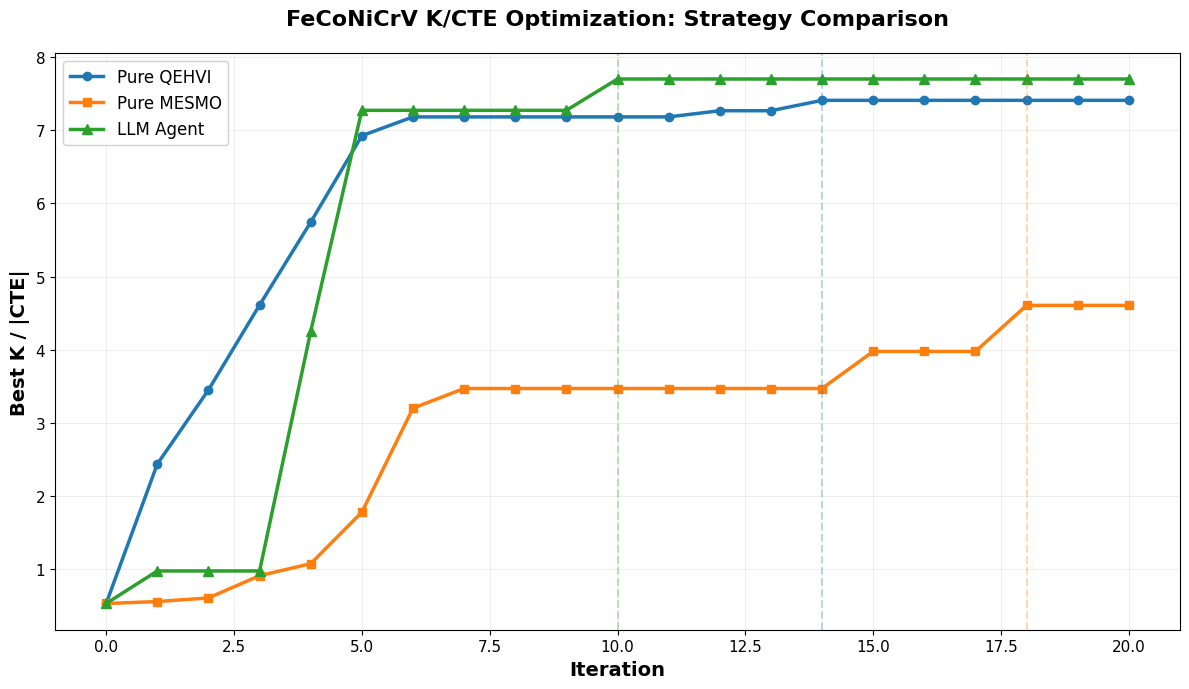

Convergence plot saved to: results/FeCoNiCrV_K_CTE_Comparison_20260204_132012\convergence_comparison.png


In [14]:
# Plot best score convergence over iterations
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each strategy
ax.plot(df_qehvi['iteration'], df_qehvi['best_score'], 
        marker='o', linewidth=2.5, label='Pure QEHVI', markersize=6)
ax.plot(df_mesmo['iteration'], df_mesmo['best_score'], 
        marker='s', linewidth=2.5, label='Pure MESMO', markersize=6)
ax.plot(df_agent['iteration'], df_agent['best_score'], 
        marker='^', linewidth=2.5, label='LLM Agent', markersize=7)

# Mark where max was achieved
ax.axvline(x=qehvi_max_iter, color='C0', linestyle='--', alpha=0.3, linewidth=1.5)
ax.axvline(x=mesmo_max_iter, color='C1', linestyle='--', alpha=0.3, linewidth=1.5)
ax.axvline(x=agent_max_iter, color='C2', linestyle='--', alpha=0.3, linewidth=1.5)

ax.set_xlabel('Iteration', fontsize=14, fontweight='bold')
ax.set_ylabel(f'Best {SCORE_NAME}', fontsize=14, fontweight='bold')
ax.set_title('FeCoNiCrV K/CTE Optimization: Strategy Comparison', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.tick_params(labelsize=11)

plt.tight_layout()
convergence_path = os.path.join(OUTPUT_DIR, "convergence_comparison.png")
plt.savefig(convergence_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Convergence plot saved to: {convergence_path}")

## Cell 12: Per-Iteration Best Score Analysis

In [15]:
# Compute cumulative best score per iteration
def compute_cumulative_best(eval_df, score_fn, obj1_name, obj2_name):
    iterations = sorted(eval_df['iteration'].unique())
    cumulative_best = []
    
    for iteration in iterations:
        iter_data = eval_df[eval_df['iteration'] <= iteration]
        Y_so_far = iter_data[[obj1_name, obj2_name]].to_numpy()
        scores_so_far = score_fn(Y_so_far)
        cumulative_best.append(scores_so_far.max())
    
    return iterations, cumulative_best

qehvi_iters, qehvi_cum_best = compute_cumulative_best(eval_qehvi, score_fn, OBJ1_NAME, OBJ2_NAME)
mesmo_iters, mesmo_cum_best = compute_cumulative_best(eval_mesmo, score_fn, OBJ1_NAME, OBJ2_NAME)
agent_iters, agent_cum_best = compute_cumulative_best(eval_agent, score_fn, OBJ1_NAME, OBJ2_NAME)

# Create DataFrame
max_len = max(len(qehvi_iters), len(mesmo_iters), len(agent_iters))
per_iter_df = pd.DataFrame({
    'Iteration': range(max_len),
    'QEHVI_Best': qehvi_cum_best + [np.nan] * (max_len - len(qehvi_cum_best)),
    'MESMO_Best': mesmo_cum_best + [np.nan] * (max_len - len(mesmo_cum_best)),
    'Agent_Best': agent_cum_best + [np.nan] * (max_len - len(agent_cum_best)),
})

print("\nCumulative Best Score per Iteration:")
print(per_iter_df.to_string(index=False))

# Save to CSV
per_iter_path = os.path.join(OUTPUT_DIR, "per_iteration_best_scores.csv")
per_iter_df.to_csv(per_iter_path, index=False)
print(f"\nPer-iteration data saved to: {per_iter_path}")


Cumulative Best Score per Iteration:
 Iteration  QEHVI_Best  MESMO_Best  Agent_Best
         0    0.531674    0.531674    0.531674
         1    2.438156    0.558312    0.976430
         2    3.450660    0.607600    0.976430
         3    4.611796    0.911921    0.976430
         4    5.744538    1.075786    4.251167
         5    6.926778    1.779183    7.273681
         6    7.183793    3.201604    7.273681
         7    7.183793    3.470878    7.273681
         8    7.183793    3.470878    7.273681
         9    7.183793    3.470878    7.273681
        10    7.183793    3.470878    7.701982
        11    7.183793    3.470878    7.701982
        12    7.268230    3.470878    7.701982
        13    7.268230    3.470878    7.701982
        14    7.410446    3.470878    7.701982
        15    7.410446    3.977568    7.701982
        16    7.410446    3.977568    7.701982
        17    7.410446    3.977568    7.701982
        18    7.410446    4.607179    7.701982
        19    7.410446

## Cell 13: Final Summary

In [16]:
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"\n📊 Experimental Setup:")
print(f"  Problem: FeCoNiCrV K/CTE Optimization")
print(f"  Objective: Maximize {SCORE_NAME}")
print(f"  Shared initial samples: {INIT_N}")
print(f"  BO iterations: {ITERS}")
print(f"  Batch size: {TOTAL_BATCH_SIZE}")
print(f"  Total evaluations per strategy: {INIT_N + ITERS * TOTAL_BATCH_SIZE}")
print(f"  Random seed: {SEED}")

print(f"\n🏆 Best Results:")
print(f"  Pure QEHVI: {qehvi_max_score:.4f} (iteration {qehvi_max_iter})")
print(f"  Pure MESMO: {mesmo_max_score:.4f} (iteration {mesmo_max_iter})")
print(f"  LLM Agent:  {agent_max_score:.4f} (iteration {agent_max_iter})")

print(f"\n📈 Mean Performance:")
print(f"  Pure QEHVI: {np.mean(scores_qehvi):.4f} ± {np.std(scores_qehvi):.4f}")
print(f"  Pure MESMO: {np.mean(scores_mesmo):.4f} ± {np.std(scores_mesmo):.4f}")
print(f"  LLM Agent:  {np.mean(scores_agent):.4f} ± {np.std(scores_agent):.4f}")

print(f"\n" + "="*80)
print(f"All results saved to: {OUTPUT_DIR}")
print("="*80)


FINAL SUMMARY

📊 Experimental Setup:
  Problem: FeCoNiCrV K/CTE Optimization
  Objective: Maximize K / |CTE|
  Shared initial samples: 5
  BO iterations: 20
  Batch size: 5
  Total evaluations per strategy: 105
  Random seed: 42

🏆 Best Results:
  Pure QEHVI: 7.4104 (iteration 14)
  Pure MESMO: 4.6072 (iteration 18)
  LLM Agent:  7.7020 (iteration 10)

📈 Mean Performance:
  Pure QEHVI: 2.5699 ± 2.3856
  Pure MESMO: 0.7202 ± 0.8172
  LLM Agent:  1.8661 ± 2.3470

All results saved to: results/FeCoNiCrV_K_CTE_Comparison_20260204_132012
